In [1]:
from google.colab import drive
drive.mount("/content/drive")

import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression

DOSSIER = "/content/drive/MyDrive/aeroguard"
os.makedirs(f"{DOSSIER}/results/figures", exist_ok=True)
os.makedirs(f"{DOSSIER}/models", exist_ok=True)

W_COLS = ["alt", "Mach", "TRA", "T2"]
CAPTEURS = ["T24", "T30", "T48", "T50", "P15", "P2", "P21", "P24",
            "Ps30", "P40", "P50", "Nf", "Nc", "Wf"]
N_VOLS_SAINS = 15

Mounted at /content/drive


In [2]:
dev = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_dev.parquet")
test = pd.read_parquet(f"{DOSSIER}/data/processed/ds01_test.parquet")
print("dev :", dev.shape, "| moteurs", sorted(dev["unit"].unique()))
print("test:", test.shape, "| moteurs", sorted(test["unit"].unique()))

dev : (4906636, 33) | moteurs [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6)]
test: (2735232, 33) | moteurs [np.int32(7), np.int32(8), np.int32(9), np.int32(10)]


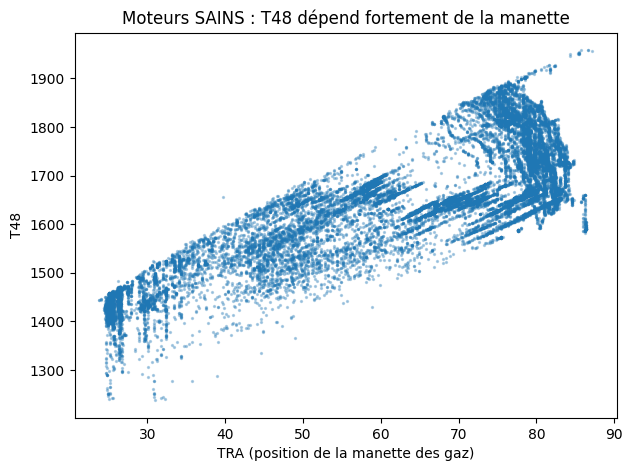

In [3]:
sains = dev[dev["cycle"] <= N_VOLS_SAINS]
petit = sains.sample(20_000, random_state=42)

plt.figure(figsize=(7, 5))
plt.scatter(petit["TRA"], petit["T48"], s=2, alpha=0.3)
plt.xlabel("TRA (position de la manette des gaz)")
plt.ylabel("T48")
plt.title("Moteurs SAINS : T48 dépend fortement de la manette")
plt.show()

In [4]:
echantillon = sains.sample(300_000, random_state=42)

modele = make_pipeline(
    StandardScaler(),
    PolynomialFeatures(degree=2),
    LinearRegression()
)
modele.fit(echantillon[W_COLS], echantillon[CAPTEURS])
print("Modèle entraîné sur", len(echantillon), "secondes de vols sains")

Modèle entraîné sur 300000 secondes de vols sains


In [5]:
def calculer_residus(df, modele):
    attendu = modele.predict(df[W_COLS])
    residus = df[CAPTEURS].to_numpy() - attendu
    sortie = df[["unit", "cycle", "hs", "RUL"]].copy()
    sortie[CAPTEURS] = residus.astype("float32")
    return sortie

res_dev = calculer_residus(dev, modele)
res_test = calculer_residus(test, modele)
res_dev.head()

,unit,cycle,hs,RUL,T24,T30,T48,T50,P15,P2,P21,P24,Ps30,P40,P50,Nf,Nc,Wf
0,1,1,1,99,0.066284,0.470337,0.799438,0.729004,0.050814,0.031000,0.051588,0.063810,1.999664,2.008728,0.055729,0.037354,0.575195,0.036868
1,1,1,1,99,0.063293,0.427124,0.742432,0.697754,0.050756,0.031211,0.051533,0.063772,1.964844,1.973633,0.054934,-0.009277,0.430664,0.036386
2,1,1,1,99,0.057312,0.421753,0.777832,0.736572,0.051022,0.031595,0.051796,0.063818,1.972382,1.980530,0.055768,-0.034180,0.393555,0.036663
3,1,1,1,99,0.037659,0.435181,0.913208,0.856201,0.049332,0.030920,0.050083,0.060911,1.980286,1.986267,0.056356,-0.194336,0.404297,0.037412
4,1,1,1,99,0.063965,0.431396,0.714478,0.668701,0.051086,0.031195,0.051867,0.064470,1.975037,1.984344,0.055070,0.006348,0.456055,0.036468


In [6]:
sain = dev["cycle"] <= N_VOLS_SAINS
for capteur in ["T48", "T50", "Wf"]:
    brut = dev.loc[sain, capteur].std()
    resid = res_dev.loc[sain, capteur].std()
    print(f"{capteur:5s} | écart-type brut : {brut:10.3f} | résidu : {resid:8.3f} | divisé par {brut/resid:6.1f}")

T48   | écart-type brut :    122.060 | résidu :    2.137 | divisé par   57.1
T50   | écart-type brut :     61.986 | résidu :    1.755 | divisé par   35.3
Wf    | écart-type brut :      0.778 | résidu :    0.017 | divisé par   45.9


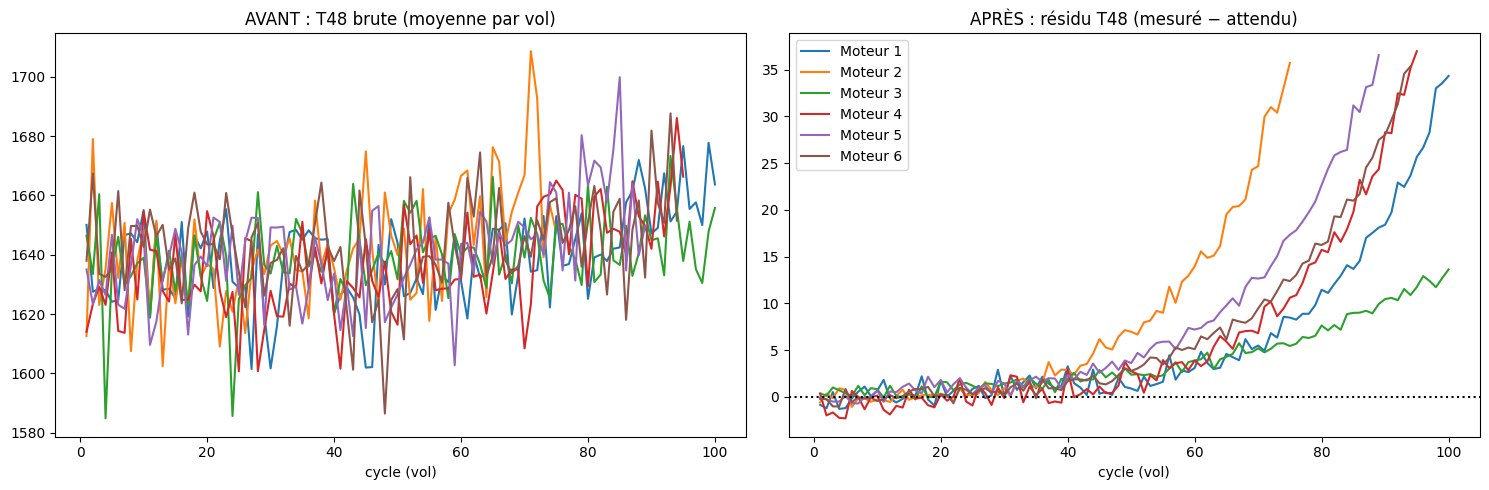

In [7]:
brut_vols = dev.groupby(["unit", "cycle"])["T48"].mean().reset_index()
res_vols = res_dev.groupby(["unit", "cycle"])[CAPTEURS].mean().reset_index()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))
for u in res_vols["unit"].unique():
    b = brut_vols[brut_vols["unit"] == u]
    r = res_vols[res_vols["unit"] == u]
    ax1.plot(b["cycle"], b["T48"], label=f"Moteur {u}")
    ax2.plot(r["cycle"], r["T48"], label=f"Moteur {u}")

ax1.set_title("AVANT : T48 brute (moyenne par vol)")
ax2.set_title("APRÈS : résidu T48 (mesuré − attendu)")
ax2.axhline(0, color="black", linestyle=":")
for ax in (ax1, ax2):
    ax.set_xlabel("cycle (vol)")
ax2.legend()
plt.tight_layout()
plt.savefig(f"{DOSSIER}/results/figures/15_avant_apres_normalisation.png", dpi=120)
plt.show()

In [8]:
debut = res_vols[res_vols["cycle"] <= N_VOLS_SAINS]
fin = res_vols.groupby("unit").tail(10)          # 10 derniers vols de chaque moteur

score = (fin[CAPTEURS].mean() - debut[CAPTEURS].mean()) / debut[CAPTEURS].std()
print(score.sort_values(key=abs, ascending=False).round(1))

T50     32.700001
T48     31.200001
T24     14.800000
Nc     -14.400000
Wf       9.500000
P24      6.800000
T30     -6.200000
P40     -5.800000
Ps30    -5.000000
P50     -1.000000
P15      0.800000
P21      0.800000
Nf      -0.100000
P2       0.000000
dtype: float32


In [9]:
res_vols.to_parquet(f"{DOSSIER}/data/processed/ds01_dev_residus_vols.parquet")
res_test.groupby(["unit", "cycle"])[CAPTEURS].mean().reset_index() \
        .to_parquet(f"{DOSSIER}/data/processed/ds01_test_residus_vols.parquet")
joblib.dump(modele, f"{DOSSIER}/models/modele_sain.joblib")
print("Sauvegardé ✅")

Sauvegardé ✅
